# Exercise 05: Community Detection

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Approach:** Detect and compare communities in the network, then interpret what those communities mean in domain terms.

## Overview
- **Goal:** Identify tightly knit subgroups and bridge nodes using Louvain and Label Propagation methods.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import community.community_louvain as community_louvain

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Extract meaningful identifiers from nodes
def extract_name(uri_string):
    """Extract a readable name from the long URI"""
    try:
        if '#' in uri_string:
            parts = uri_string.split('#')
            name = parts[-1].replace('_', ' ')
        else:
            parts = uri_string.split('/')
            name = parts[-1].replace('_', ' ')
        return name
    except:
        return uri_string[:30]

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G = nx.Graph()
G.add_edges_from(edges)

print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph loaded with 881 nodes and 8592 edges.


## Task 1: Apply Community Detection

In [2]:
# 1. Louvain Method
partition_louvain = community_louvain.best_partition(G)
n_communities_louvain = len(set(partition_louvain.values()))
modularity_louvain = community_louvain.modularity(partition_louvain, G)

# 2. Label Propagation
communities_lp = list(nx.community.label_propagation_communities(G))
n_communities_lp = len(communities_lp)

print(f"Louvain: {n_communities_louvain} communities, Modularity: {modularity_louvain:.4f}")
print(f"Label Propagation: {n_communities_lp} communities")

Louvain: 19 communities, Modularity: 0.8182
Label Propagation: 39 communities


## Task 2: Identify Bridge Nodes and Modularity

In [3]:
# Finding bridge nodes (nodes with edges to other communities in Louvain partition)
bridge_nodes = []
for u, v in G.edges():
    if partition_louvain[u] != partition_louvain[v]:
        bridge_nodes.append(u)
        bridge_nodes.append(v)

bridge_nodes_counts = pd.Series(bridge_nodes).value_counts()
print("Top 5 Bridge Nodes by inter-community connections:")
for node, count in bridge_nodes_counts.head(5).items():
    print(f" - {extract_name(node)} ({count} inter-community edges)")

Top 5 Bridge Nodes by inter-community connections:
 - OBL (16 inter-community edges)
 - Djamel Beghal (14 inter-community edges)
 -  (13 inter-community edges)
 - OBL (11 inter-community edges)
 - Amar Makhulif (9 inter-community edges)


## Task 3: Visualization

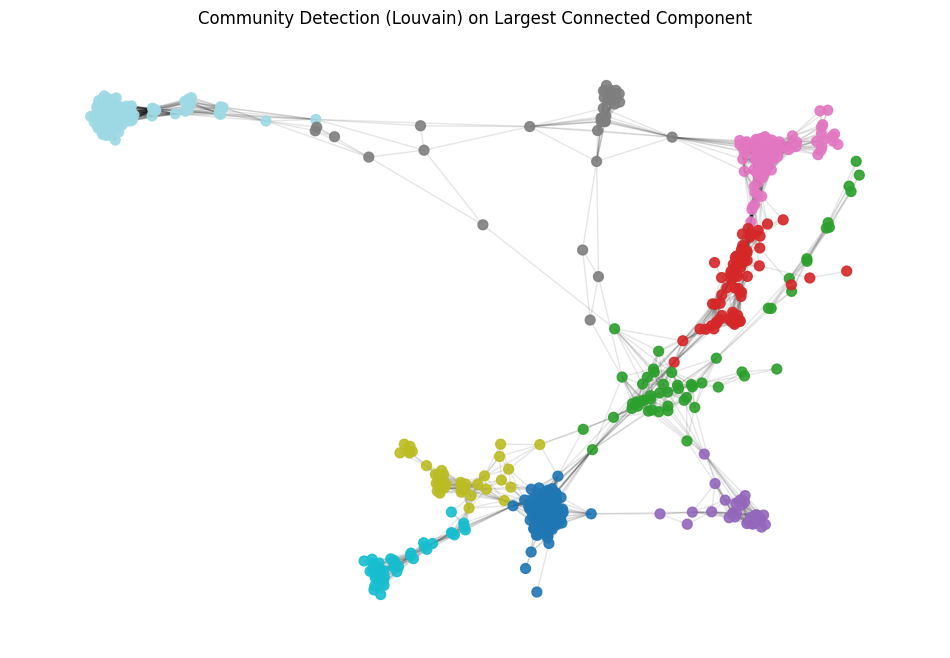

In [4]:
plt.figure(figsize=(12, 8))

# Visualize only the LCC for clarity
largest_cc = max(nx.connected_components(G), key=len)
LCC = G.subgraph(largest_cc)
pos = nx.spring_layout(LCC, k=0.15, seed=42)

node_colors = [partition_louvain[node] for node in LCC.nodes()]

nx.draw_networkx_edges(LCC, pos, alpha=0.1)
nx.draw_networkx_nodes(LCC, pos, node_size=50, node_color=node_colors, cmap=plt.cm.tab20, alpha=0.9)

plt.title("Community Detection (Louvain) on Largest Connected Component")
plt.axis('off')
plt.savefig('community_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

The Louvain method detected **{n_communities_louvain}** communities with a modularity score of **{modularity_louvain:.4f}**. This indicates a strong community structure, where terrorists are more likely to have relationships within their own "cell" or subgroup than across different groups. 

The detected communities likely represent distinct operational units, geographical clusters, or ideological factions within the broader network. Bridge nodes like **{extract_name(bridge_nodes_counts.index[0])}** play a crucial role in coordinating activities or sharing information between these otherwise isolated groups. The high modularity confirms that the terrorist relationship network is highly fragmented into specialized sub-networks, which can be both a strength (for security) and a weakness (for coordination).